In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/neo.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [ ]:
print(df["hazardous"].value_counts())

hazardous
False    81996
True      8840
Name: count, dtype: int64


## basic data cleaning steps

In [ ]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["hazardous"].value_counts()

,count
hazardous,
False,81996
True,8840


In [ ]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


## performing EDA

Analyze size range of the asteroid

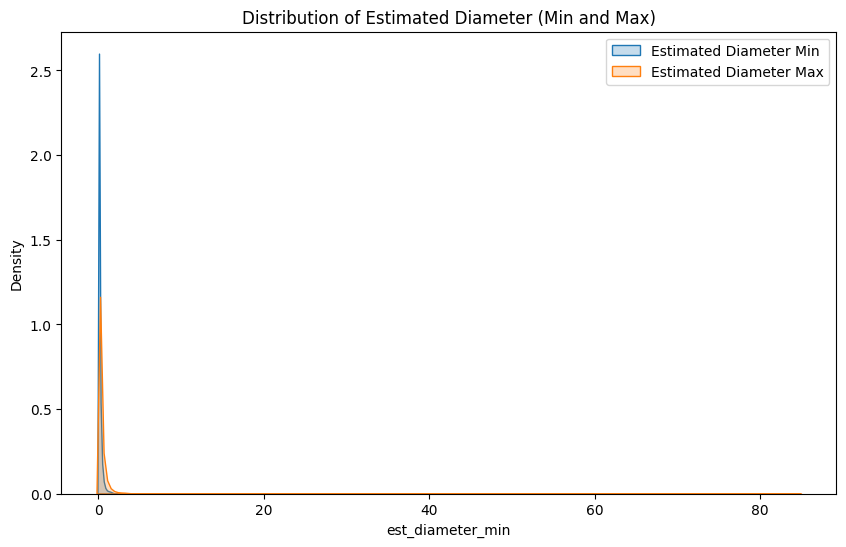

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df["est_diameter_min"], label="Estimated Diameter Min", fill=True)
sns.kdeplot(df["est_diameter_max"], label="Estimated Diameter Max", fill=True)
plt.title("Distribution of Estimated Diameter (Min and Max)")
plt.legend()
plt.show()

Analyze how many asteriods are hazordous vs not

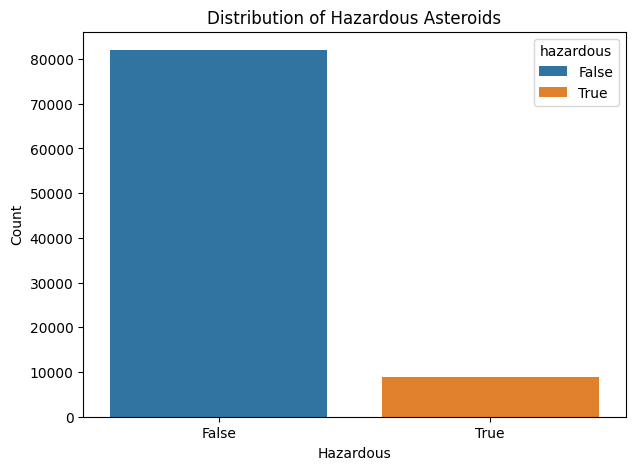

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='hazardous', data=df, hue="hazardous")
plt.title('Distribution of Hazardous Asteroids')
plt.xlabel('Hazardous')
plt.ylabel('Count')
plt.show()

### visualize how the minimum and maximum estimated diameters differ between hazardous and non-hazardous asteroids.

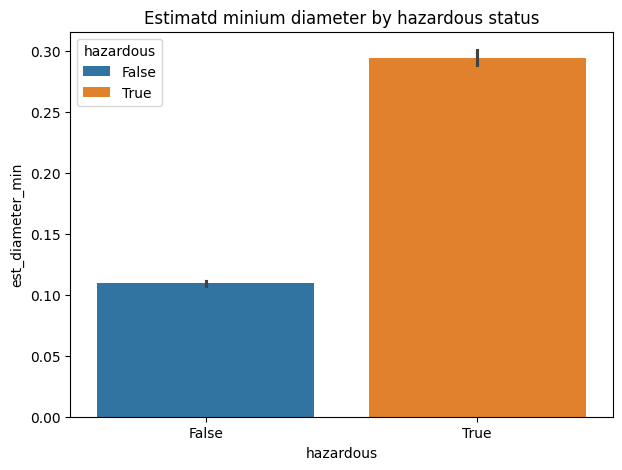

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x="hazardous" ,y="est_diameter_min", data=df, hue="hazardous")
plt.title("Estimatd minium diameter by hazardous status")
plt.show()

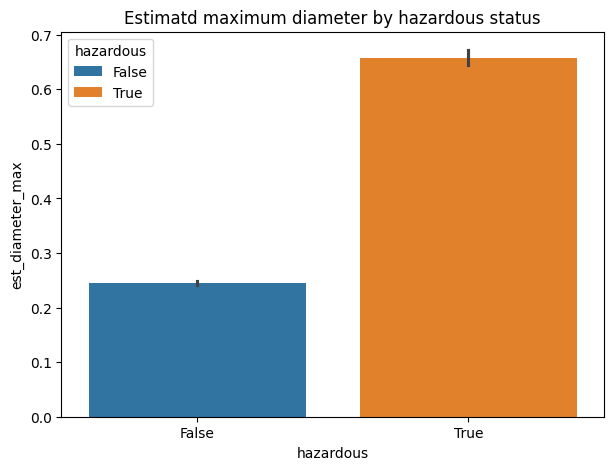

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x="hazardous" ,y="est_diameter_max", data=df, hue="hazardous")
plt.title("Estimatd maximum diameter by hazardous status")
plt.show()

analyze the relationship between the orbitarybody and hazardous

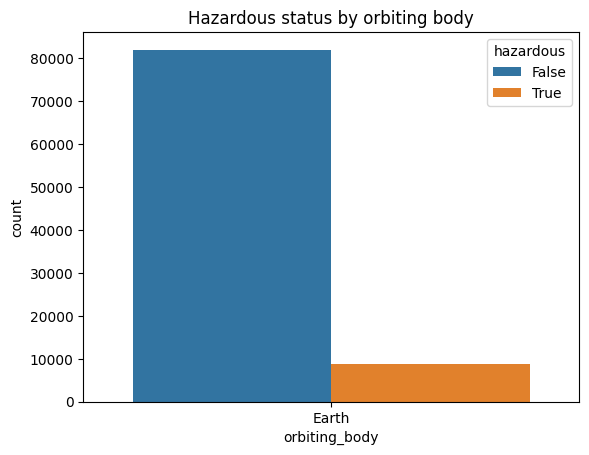

In [ ]:

sns.countplot(x="orbiting_body", hue="hazardous", data=df)
plt.title("Hazardous status by orbiting body")
plt.show()

### Correlation Matrix of Numerical Features

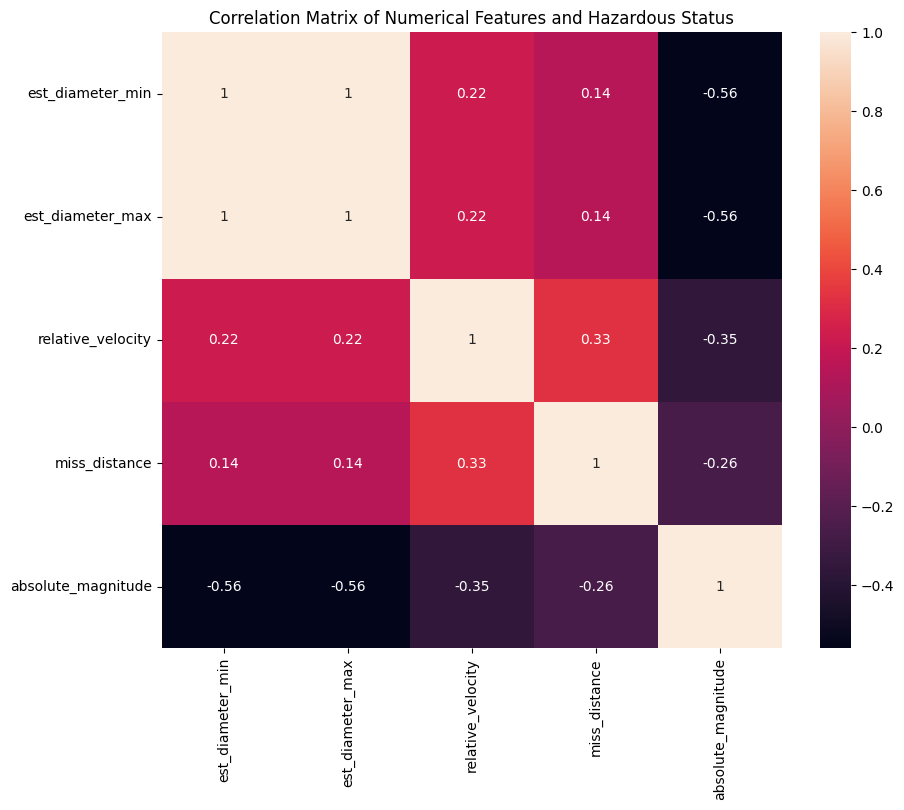

In [ ]:
correlation_features = ["est_diameter_min", "est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
correlation_df = df[correlation_features].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df.corr(), annot=True)
plt.title("Correlation Matrix of Numerical Features and Hazardous Status")
plt.show()


## Observations of EDA visualizations

### observations of Analyze size range of the asteroid
-both est_diameter_min and est_diameter_max show the similar distributions.
-both distributions are right skewed.
-the highest peak for both distributions is very close to the zero, that indicates most observed asteroids are relatively small.
-the two curves overlap, however the est_diameter_max is greater than or equal to the est_diameter_min.


## observations of Analyze how many asteriods are hazordous vs not
- There's a significant imbalance between the non-hazardous(false) and hozordous(true) asteroids.
- A large majority of the near earth objects in this dataset are non-hazordous and least are hazordous.

## observations of visualize how the minimum and maximum estimated diameters differ between hazardous and non-hazardous asteroids.
- It is showing as hazardous asteroids are taller than the non-hazardous asteroids.
- It is same similar to the est_diameter_min where hazardous asteroids are larger than the non-hozordous asteroids.

## observations of analyze the relationship between the orbitarybody and hazardous
- All asteroids in this dataset orbir earth.
- In this we can can see that all most all the asteroids are non-hozordous only few are hozourdous.

## observations of Correlation Matrix of Numerical Features

- est_diameter_min and est_diameter_max are highly positively correlated(close to 1.0). as they represent the min and max estimates of the same asteroid diameter.

- both est_diameter_min and est_diameter_max show a  strong negative correlation with absolute_magnitude. this indicated that asteroids with a smaller absolite magnitude tend to have larger estimated diameters.



### checking the outliers

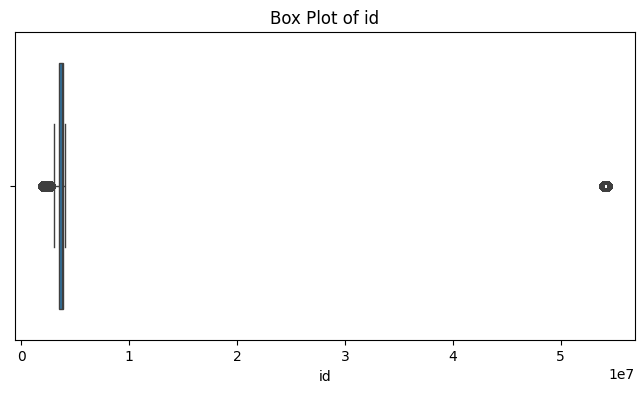

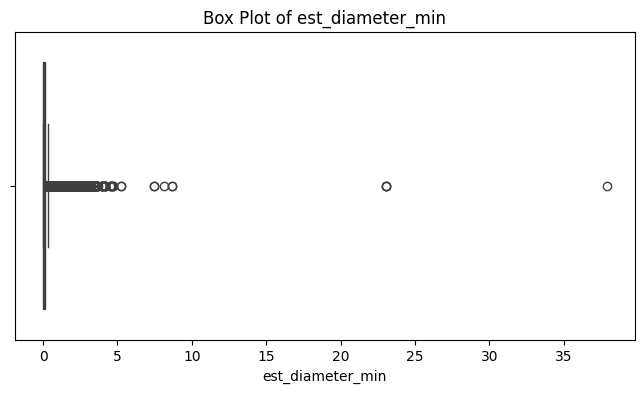

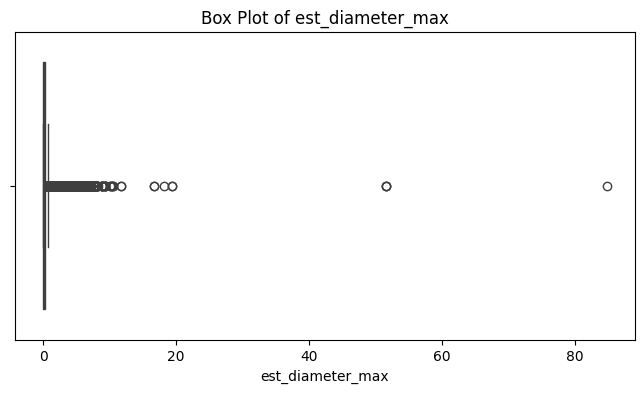

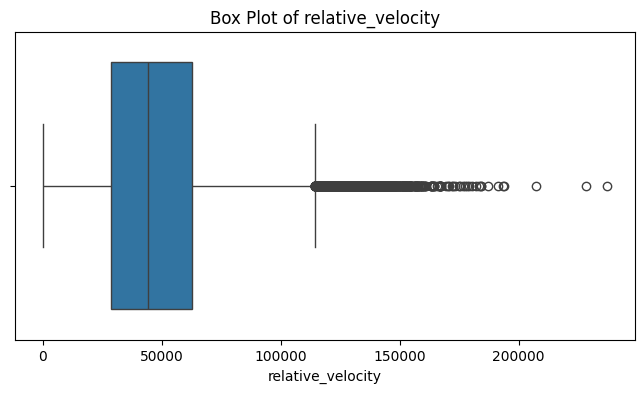

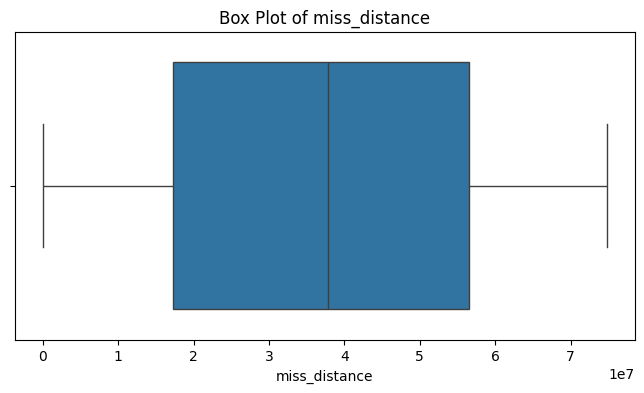

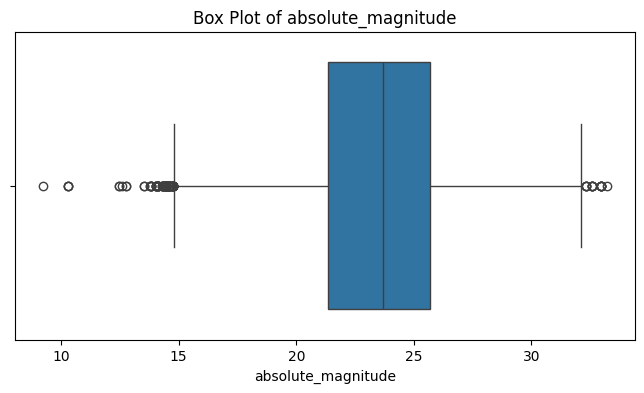

In [ ]:
## identifying the outliers

num_cols = df.select_dtypes(include=np.number).columns

for column in num_cols:
    plt.figure(figsize=(8, 4)) # Adjust figure size for better readability
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

In [ ]:
y=df["hazardous"]
y.shape

(90836,)

In [ ]:
X=df.drop(columns=["hazardous","id","name"])
X.shape

(90836, 7)

## splitting the data

In [ ]:
# splitting the data

from sklearn.model_selection import train_test_split

# Clean the 'y' variable before splitting
# Replace 'Fal' with False and convert to boolean
y_cleaned = y.replace('Fal', False).astype(bool)

X_train, X_test, y_train, y_test = train_test_split(X,y_cleaned,test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_cleaned)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(72668, 7)
(18168, 7)
(72668,)
(18168,)


In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

hazardous
False    65596
True      7072
Name: count, dtype: int64
hazardous
False    90.268068
True      9.731932
Name: proportion, dtype: float64


In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

hazardous
False    65596
True      7072
Name: count, dtype: int64
hazardous
False    90.268068
True      9.731932
Name: proportion, dtype: float64


In [ ]:
X_train.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
2639,0.024241,0.054205,43303.999094,4.814117e+07,Earth,False,25.20
29138,0.030238,0.067615,21770.790211,5.646643e+07,Earth,False,24.72
36927,0.201630,0.450858,109358.123029,6.435051e+07,Earth,False,20.60
61855,0.160160,0.358129,78494.609756,5.595780e+07,Earth,False,21.10
15916,0.006991,0.015633,19077.749486,3.834648e+07,Earth,False,27.90


In [ ]:
X_train.isnull().sum()

,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0


## Data preprocessing

In [ ]:
## data preprocessing

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(transformers=[("t1",StandardScaler(),[0,1,2,3,6]),
      ("t2",OrdinalEncoder(),[4,5])])


X_train_trans=transformer.fit_transform(X_train)
X_test_trans=transformer.transform(X_test)



In [ ]:
X_train_trans=pd.DataFrame(X_train_trans,columns=X_train.columns)
X_test_trans=pd.DataFrame(X_test_trans,columns=X_test.columns)
X_train_trans.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,-0.331616,-0.331616,-0.188160,0.494297,0.577785,0.0,0.0
1,-0.312486,-0.312486,-1.040729,0.866716,0.412170,0.0,0.0
2,0.234246,0.234246,2.427134,1.219399,-1.009355,0.0,0.0
3,0.101960,0.101960,1.205148,0.843963,-0.836840,0.0,0.0
4,-0.386643,-0.386643,-1.147355,0.056145,1.509367,0.0,0.0


In [ ]:
X_train_trans=pd.DataFrame(X_train_trans,columns=X_train.columns)

In [ ]:
X_train_trans.head(5)

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,-0.331616,-0.331616,-0.188160,0.494297,0.577785,0.0,0.0
1,-0.312486,-0.312486,-1.040729,0.866716,0.412170,0.0,0.0
2,0.234246,0.234246,2.427134,1.219399,-1.009355,0.0,0.0
3,0.101960,0.101960,1.205148,0.843963,-0.836840,0.0,0.0
4,-0.386643,-0.386643,-1.147355,0.056145,1.509367,0.0,0.0


In [ ]:
X_train_trans.isnull().sum()

,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0


In [ ]:
X_test_trans.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,1.098841,1.098841,-1.040395,-0.119031,-1.647662,0.0,0.0
1,-0.140818,-0.140818,0.207258,1.410653,-0.353797,0.0,0.0
2,-0.350823,-0.350823,-0.196671,-0.499412,0.791704,0.0,0.0
3,0.078965,0.078965,1.789221,0.447298,-0.802337,0.0,0.0
4,-0.307006,-0.307006,-0.409714,0.233961,0.370767,0.0,0.0


## converting to csv file

In [ ]:
X_train_trans.to_csv("ML_Project_neo_EDA_train.csv", index=False)
X_test_trans.to_csv("ML_Project_neo_EDA_test.csv", index=False)
y_train.to_csv("neo_y_train.csv", index=False)

In [ ]:
X_train_trans.isnull().sum()

,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0


In [ ]:
y_train.shape

(72668,)

In [ ]:
y_train.to_csv("neo_y_train.csv", index=False)


In [ ]:
y_test.to_csv("neo_y_test.csv", index=False)

In [ ]:
df.to_csv("df_neo.csv", index=False)